# 03. Bureau 조인 - 외부 신용이력 통합

**목적**: `bureau.csv`(다른 은행 신용기록)를 `application_train`에 조인해서 예측 변수를 늘린다.

- **분석 질문**
  1. 다른 은행에서 받은 신용기록이 부도 예측에 추가 신호인가?
  2. 신용기록 *건수·최근성·연체 이력*이 부도율에 어떻게 작용하는가?
  3. 조인 후 파생된 변수들이 단변량으로 의미 있는 신호를 보이는가?

- **산출물**
  - 조인·집계된 master 데이터 → `outputs/tables/03_application_with_bureau.parquet`
  - 신규 파생 변수 약 40개 (count·sum·max·mean + 상태별 더미)

> 실무 관점: 여러 테이블을 집계·조인하는 건 Kaggle 노트북 대부분이 생략하는 부분이다.
> SQL group by + join 패턴을 pandas로 구현하는 게 핵심.

## 0. 환경 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

installed = {f.name for f in fm.fontManager.ttflist}
for name in ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Gulim']:
    if name in installed:
        plt.rcParams['font.family'] = name
        print('한글 폰트:', name)
        break

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 200)

DATA_DIR = Path('../data/raw')
OUT_FIG  = Path('../outputs/figures')
OUT_TBL  = Path('../outputs/tables')

print('준비 완료')

한글 폰트: Malgun Gothic
준비 완료


## 1. 데이터 로딩

두 파일을 각각 올린다. bureau는 application의 한 고객(SK_ID_CURR)당 여러 행이 있다.

In [3]:
app = pd.read_csv(DATA_DIR / 'application_train.csv')
bureau = pd.read_csv(DATA_DIR / 'bureau.csv')

print(f'application : {app.shape}  (행 {app.shape[0]:,} / 열 {app.shape[1]})')
print(f'bureau      : {bureau.shape}  (행 {bureau.shape[0]:,} / 열 {bureau.shape[1]})')
print(f'\n전체 부도율: {app["TARGET"].mean()*100:.2f}%')

application : (307511, 122)  (행 307,511 / 열 122)
bureau      : (1716428, 17)  (행 1,716,428 / 열 17)

전체 부도율: 8.07%


## 2. bureau 구조 파악

컬럼 의미를 먼저 이해하고, 고객당 기록 수 분포를 본다.

In [4]:
print('컬럼 목록 & 타입:')
print(bureau.dtypes)
print()
bureau.head(3)

컬럼 목록 & 타입:
SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE              object
CREDIT_CURRENCY            object
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                object
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64
dtype: object



,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN


In [5]:
miss = (bureau.isnull().mean() * 100).round(2).sort_values(ascending=False)
print('결측률(%) - 상위 10개:'); print(miss[miss > 0])

결측률(%) - 상위 10개:
AMT_ANNUITY               71.47
AMT_CREDIT_MAX_OVERDUE    65.51
DAYS_ENDDATE_FACT         36.92
AMT_CREDIT_SUM_LIMIT      34.48
AMT_CREDIT_SUM_DEBT       15.01
DAYS_CREDIT_ENDDATE        6.15
dtype: float64


고객당 bureau 기록 수 분포:
count    305811.0
mean          5.6
std           4.4
min           1.0
25%           2.0
50%           4.0
75%           8.0
max         116.0
dtype: float64

application 고객 307,511명 중
bureau 기록 있는 고객: 305,811명
bureau 기록 없는 고객: 1,700명


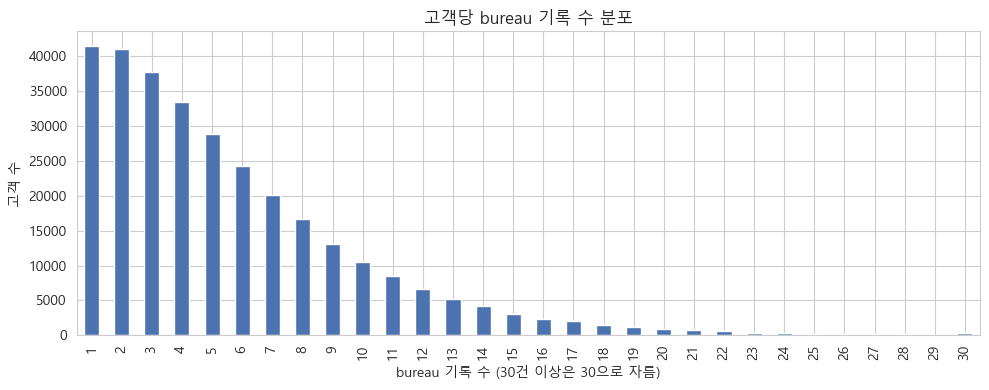

In [6]:
# 고객 1명당 bureau 기록이 몇 개인지
cnt_per_customer = bureau.groupby('SK_ID_CURR').size()
print('고객당 bureau 기록 수 분포:')
print(cnt_per_customer.describe().round(1))
print(f'\napplication 고객 {app["SK_ID_CURR"].nunique():,}명 중')
print(f'bureau 기록 있는 고객: {cnt_per_customer.index.nunique():,}명')
print(f'bureau 기록 없는 고객: {app["SK_ID_CURR"].nunique() - cnt_per_customer.index.nunique():,}명')

fig, ax = plt.subplots(figsize=(10, 4))
cnt_per_customer.clip(upper=30).value_counts().sort_index().plot.bar(ax=ax, color='#4C72B0')
ax.set_xlabel('bureau 기록 수 (30건 이상은 30으로 자름)')
ax.set_ylabel('고객 수')
ax.set_title('고객당 bureau 기록 수 분포')
plt.tight_layout()
plt.savefig(OUT_FIG / '03_bureau_count_dist.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
# 범주형 컬럼 분포
for col in ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']:
    print(f'\n{col}:')
    print(bureau[col].value_counts())


CREDIT_ACTIVE:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

CREDIT_CURRENCY:
CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

CREDIT_TYPE:
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase 

## 3. bureau 집계 (SK_ID_CURR 기준)

bureau는 고객 1명당 여러 행이라 집계(group by)가 필요하다.
- 수치형: min / max / mean / sum
- 범주형: 상태(CREDIT_ACTIVE), 통화(CREDIT_CURRENCY)별 건수

In [8]:
num_cols = [
    'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_CREDIT_UPDATE',
    'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT',
    'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE',
    'CNT_CREDIT_PROLONG', 'AMT_ANNUITY'
]

agg_funcs = {col: ['min', 'max', 'mean', 'sum'] for col in num_cols}
bureau_num = bureau.groupby('SK_ID_CURR').agg(agg_funcs)
bureau_num.columns = [f'bureau_{c[0]}_{c[1]}' for c in bureau_num.columns]

# 기록 건수 추가
bureau_num['bureau_count'] = bureau.groupby('SK_ID_CURR').size()

print(f'수치형 집계 shape: {bureau_num.shape}')
bureau_num.head(3)

수치형 집계 shape: (305811, 37)


,bureau_DAYS_CREDIT_min,bureau_DAYS_CREDIT_max,bureau_DAYS_CREDIT_mean,bureau_DAYS_CREDIT_sum,bureau_DAYS_CREDIT_ENDDATE_min,bureau_DAYS_CREDIT_ENDDATE_max,bureau_DAYS_CREDIT_ENDDATE_mean,bureau_DAYS_CREDIT_ENDDATE_sum,bureau_DAYS_CREDIT_UPDATE_min,bureau_DAYS_CREDIT_UPDATE_max,bureau_DAYS_CREDIT_UPDATE_mean,bureau_DAYS_CREDIT_UPDATE_sum,bureau_AMT_CREDIT_SUM_min,bureau_AMT_CREDIT_SUM_max,bureau_AMT_CREDIT_SUM_mean,bureau_AMT_CREDIT_SUM_sum,bureau_AMT_CREDIT_SUM_DEBT_min,bureau_AMT_CREDIT_SUM_DEBT_max,bureau_AMT_CREDIT_SUM_DEBT_mean,bureau_AMT_CREDIT_SUM_DEBT_sum,bureau_AMT_CREDIT_SUM_LIMIT_min,bureau_AMT_CREDIT_SUM_LIMIT_max,bureau_AMT_CREDIT_SUM_LIMIT_mean,bureau_AMT_CREDIT_SUM_LIMIT_sum,bureau_AMT_CREDIT_SUM_OVERDUE_min,bureau_AMT_CREDIT_SUM_OVERDUE_max,bureau_AMT_CREDIT_SUM_OVERDUE_mean,bureau_AMT_CREDIT_SUM_OVERDUE_sum,bureau_CNT_CREDIT_PROLONG_min,bureau_CNT_CREDIT_PROLONG_max,bureau_CNT_CREDIT_PROLONG_mean,bureau_CNT_CREDIT_PROLONG_sum,bureau_AMT_ANNUITY_min,bureau_AMT_ANNUITY_max,bureau_AMT_ANNUITY_mean,bureau_AMT_ANNUITY_sum,bureau_count
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100001,-1572,-49,-735.00,-5145,-1329.0,1778.0,82.428571,577.0,-155,-6,-93.142857,-652,85500.0,378000.0,207623.571429,1453365.000,0.0,373239.0,85240.928571,596686.5,0.0,0.000,0.00000,0.000,0.0,0.0,0.0,0.0,0,0,0.0,0,0.0,10822.5,3545.357143,24817.5,7
100002,-1437,-103,-874.00,-6992,-1072.0,780.0,-349.000000,-2094.0,-1185,-7,-499.875000,-3999,0.0,450000.0,108131.945625,865055.565,0.0,245781.0,49156.200000,245781.0,0.0,31988.565,7997.14125,31988.565,0.0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.000000,0.0,8
100003,-2586,-606,-1400.75,-5603,-2434.0,1216.0,-544.500000,-2178.0,-2131,-43,-816.000000,-3264,22248.0,810000.0,254350.125000,1017400.500,0.0,0.0,0.000000,0.0,0.0,810000.000,202500.00000,810000.000,0.0,0.0,0.0,0.0,0,0,0.0,0,NaN,NaN,NaN,0.0,4


In [9]:
# CREDIT_ACTIVE 상태별 건수
active_dummies = pd.get_dummies(bureau['CREDIT_ACTIVE'], prefix='bureau_active')
active_dummies['SK_ID_CURR'] = bureau['SK_ID_CURR'].values
bureau_active = active_dummies.groupby('SK_ID_CURR').sum()

# CREDIT_TYPE 건수
type_dummies = pd.get_dummies(bureau['CREDIT_TYPE'], prefix='bureau_type')
type_dummies['SK_ID_CURR'] = bureau['SK_ID_CURR'].values
bureau_type = type_dummies.groupby('SK_ID_CURR').sum()

# 합치기
bureau_features = bureau_num.join(bureau_active).join(bureau_type)
print(f'최종 bureau feature shape: {bureau_features.shape}')
print(f'파생 변수 수: {bureau_features.shape[1]}개')

최종 bureau feature shape: (305811, 56)
파생 변수 수: 56개


## 4. application + bureau 조인 (left join)

SK_ID_CURR 기준으로 left join. bureau 기록이 없는 고객은 NaN으로 채워진다.

In [10]:
app_bureau = app.merge(bureau_features, how='left', left_on='SK_ID_CURR', right_index=True)
print(f'조인 후 shape: {app_bureau.shape}')

no_bureau_mask = app_bureau['bureau_count'].isnull()
print(f"bureau 기록 없는 고객: {no_bureau_mask.sum():,}명 ({no_bureau_mask.mean()*100:.1f}%)")
print(f"\nbureou 기록 없는 그룹 부도율: {app_bureau.loc[no_bureau_mask, 'TARGET'].mean()*100:.2f}%")
print(f"bureau 기록 있는 그룹 부도율: {app_bureau.loc[~no_bureau_mask, 'TARGET'].mean()*100:.2f}%")

조인 후 shape: (307511, 178)
bureau 기록 없는 고객: 44,020명 (14.3%)

bureou 기록 없는 그룹 부도율: 10.12%
bureau 기록 있는 그룹 부도율: 7.73%


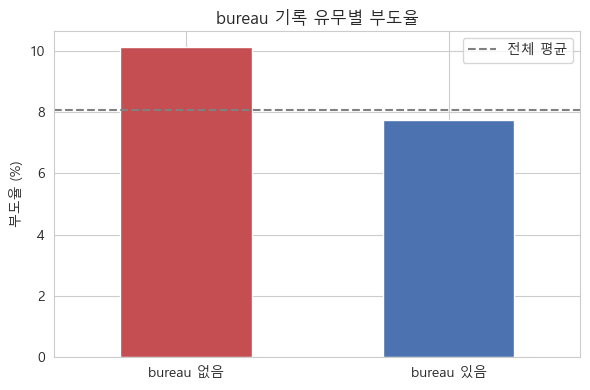

In [11]:
# 보조 변수: bureau 유무 플래그 + 0 채운 버전
app_bureau['has_bureau'] = (~no_bureau_mask).astype(int)
app_bureau['bureau_count_filled'] = app_bureau['bureau_count'].fillna(0)

fig, ax = plt.subplots(figsize=(6, 4))
rates = pd.Series({
    'bureau 없음': app_bureau.loc[no_bureau_mask, 'TARGET'].mean() * 100,
    'bureau 있음': app_bureau.loc[~no_bureau_mask, 'TARGET'].mean() * 100,
})
rates.plot.bar(ax=ax, color=['#C44E52', '#4C72B0'], rot=0)
ax.axhline(app['TARGET'].mean()*100, color='gray', ls='--', label='전체 평균')
ax.set_ylabel('부도율 (%)')
ax.set_title('bureau 기록 유무별 부도율')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / '03_has_bureau_default_rate.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. bureau 파생 변수 - 단변량 신호 확인

조인 전에 만든 변수들이 TARGET과 의미 있는 상관이 있는지 빠르게 본다.
bureau가 없는 행은 제외하고 계산.

bureau 파생 변수 TOP 20 (|상관계수|):
bureau_DAYS_CREDIT_mean            0.0897
bureau_DAYS_CREDIT_min             0.0752
bureau_DAYS_CREDIT_UPDATE_mean     0.0689
bureau_active_Active               0.0671
bureau_DAYS_CREDIT_ENDDATE_sum     0.0537
bureau_DAYS_CREDIT_max             0.0498
bureau_DAYS_CREDIT_ENDDATE_mean    0.0470
bureau_DAYS_CREDIT_UPDATE_min      0.0429
bureau_DAYS_CREDIT_sum             0.0420
bureau_DAYS_CREDIT_UPDATE_sum      0.0414
bureau_DAYS_CREDIT_ENDDATE_max     0.0366
bureau_type_Credit card            0.0348
bureau_DAYS_CREDIT_ENDDATE_min     0.0343
bureau_type_Microloan              0.0341
bureau_active_Closed               0.0308
bureau_DAYS_CREDIT_UPDATE_max      0.0282
bureau_type_Mortgage               0.0233
bureau_type_Car loan               0.0208
bureau_AMT_CREDIT_SUM_mean         0.0200
bureau_AMT_CREDIT_SUM_max          0.0197
Name: TARGET, dtype: float64


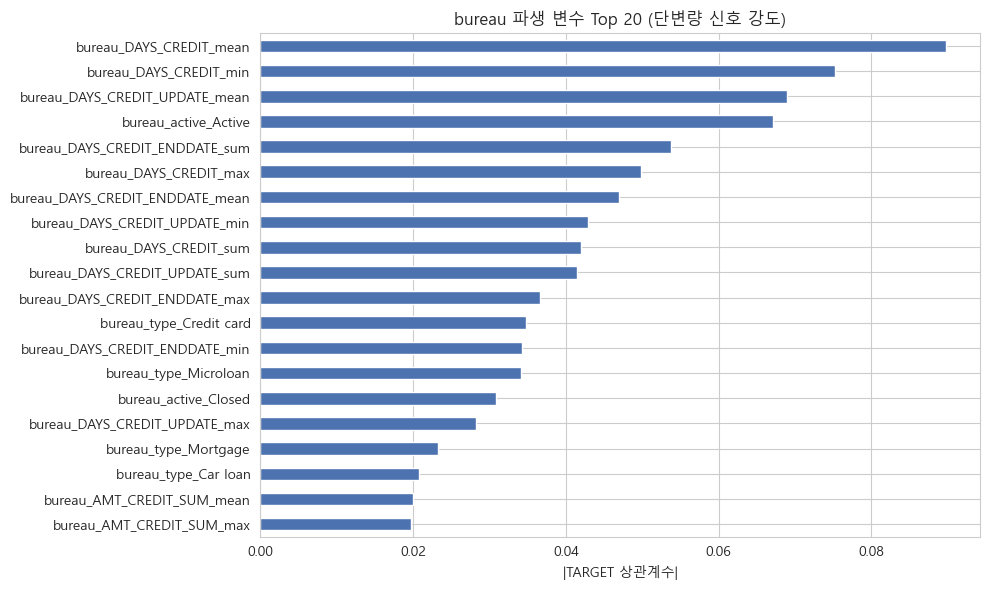

In [12]:
bureau_num_cols = [c for c in bureau_features.columns if bureau_features[c].dtype in ['float64', 'int64', 'uint8']]

# 결측치 없는 행 기준 상관계수
corr_df = (
    app_bureau[bureau_num_cols + ['TARGET']]
    .dropna(subset=['bureau_count'])
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
)

print('bureau 파생 변수 TOP 20 (|상관계수|):')
print(corr_df.head(20).round(4))

fig, ax = plt.subplots(figsize=(10, 6))
corr_df.head(20).plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('|TARGET 상관계수|')
ax.set_title('bureau 파생 변수 Top 20 (단변량 신호 강도)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_FIG / '03_bureau_feature_corr.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# 주요 변수 상세 - bureau_count vs 부도율
tmp = app_bureau.dropna(subset=['bureau_count']).copy()
tmp['bureau_count_bin'] = pd.cut(tmp['bureau_count'], bins=[0, 2, 5, 10, 20, 100], right=True)
rate_by_count = (tmp.groupby('bureau_count_bin')['TARGET'].mean() * 100).round(2)
print('bureau 기록 수 구간별 부도율(%):'); print(rate_by_count)

fig, ax = plt.subplots(figsize=(8, 4))
rate_by_count.plot.bar(ax=ax, color='#4C72B0', rot=0)
ax.axhline(app['TARGET'].mean()*100, color='#C44E52', ls='--', label='전체 평균')
ax.set_ylabel('부도율 (%)')
ax.set_xlabel('bureau 기록 수')
ax.set_title('bureau 기록 수 구간별 부도율')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / '03_bureau_count_vs_default.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# 외부 연체 누적(AMT_CREDIT_SUM_OVERDUE_sum)은 가장 직접적인 신호일 가능성
overdue_col = 'bureau_AMT_CREDIT_SUM_OVERDUE_sum'
if overdue_col in app_bureau.columns:
    tmp2 = app_bureau.dropna(subset=[overdue_col]).copy()
    tmp2['has_overdue'] = (tmp2[overdue_col] > 0).astype(int)
    rates2 = (tmp2.groupby('has_overdue')['TARGET'].mean() * 100).round(2)
    print('외부 연체 유무별 부도율(%):'); print(rates2)
    print(f'\n외부 연체 있으면 부도율 차이: +{rates2[1]-rates2[0]:.2f}%p')

외부 연체 유무별 부도율(%):
has_overdue
0     7.62
1    16.20
Name: TARGET, dtype: float64

외부 연체 있으면 부도율 차이: +8.58%p


## 6. master 데이터 저장

parquet으로 저장. 04_psm, 05_segmentation, 06_model 모두 이 파일을 읽는다.

In [15]:
out_path = OUT_TBL / '03_application_with_bureau.parquet'
app_bureau.to_parquet(out_path, index=False)

size_mb = out_path.stat().st_size / 1024**2
print(f'저장 완료: {out_path}')
print(f'파일 크기: {size_mb:.1f} MB')
print(f'최종 shape: {app_bureau.shape}')
print(f'  - 기존 application 변수: {app.shape[1]}개')
print(f'  - bureau 파생 변수: {bureau_features.shape[1]}개')
print(f'  - 보조 플래그(has_bureau, bureau_count_filled): 2개')

저장 완료: ..\outputs\tables\03_application_with_bureau.parquet
파일 크기: 44.1 MB
최종 shape: (307511, 180)
  - 기존 application 변수: 122개
  - bureau 파생 변수: 56개
  - 보조 플래그(has_bureau, bureau_count_filled): 2개


## 결론

**구조:**
- bureau 기록 있는 고객 85.7%(263,491명), 없는 고객 14.3%(44,020명).
- 파생 변수 56개 생성 (수치형 집계 37개 + CREDIT_ACTIVE 더미 4개 + CREDIT_TYPE 더미 15개).

**부도율 차이:**
- bureau 없는 그룹: **10.12%** vs 있는 그룹: **7.73%**, 2.39%p 차이.
- 신용이력 자체가 '안전' 신호. 04_psm에서 이게 인과인지 확인.

**신호 강도:**
- `bureau_AMT_CREDIT_SUM_OVERDUE_sum`이 가장 강한 bureau 신호. 연체 있으면 16.20%, 없으면 7.62%로 +8.58%p 차이. 단변량 상관계수로는 약하게 보이지만(대부분 0), 이진화하면 강력한 신호.
- `bureau_DAYS_CREDIT_mean` - 단변량 상관 0.090으로 bureau 변수 중 1위. 최근 대출이 많을수록(0에 가까울수록) 부도 위험 ↑.
- `bureau_active_Active` - 현재 진행 중인 대출 많을수록 위험. 상관 0.067.
- 전반적으로 모든 bureau 변수는 상관 0.09 이하. EXT_SOURCE_2(0.16)보다 약한 단변량 신호.

**다음 단계:**
- bureau가 *있는* 고객의 부도율이 낮은 건 진짜 인과인가, 아니면 원래 안전한 사람들이 bureau 기록이 많은 건가?
- 04_psm_causal에서 `has_bureau`를 treatment로 PSM 매칭으로 분리.